Import Libraries

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

Create Pipeline

In [12]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1,2))),
    ("clf", LogisticRegression(class_weight='balanced', max_iter=1000))
])

Train Model

In [13]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

First, let's create some sample data for demonstration. Since you're using `TfidfVectorizer` and `LogisticRegression`, this looks like a text classification task. We are generating some sample text and corresponding labels, then split them into training and testing sets.

In [14]:
from sklearn.model_selection import train_test_split

# Sample data
X = [
    "This is a great movie!",
    "I really enjoyed this film.",
    "Terrible acting and boring plot.",
    "What a waste of time.",
    "Highly recommended, a masterpiece.",
    "Never again will I watch this."
]
y = [1, 1, 0, 0, 1, 0] # 1 for positive, 0 for negative

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train samples: {X_train}")
print(f"y_train labels: {y_train}")
print(f"X_test samples: {X_test}")
print(f"y_test labels: {y_test}")

X_train samples: ['Never again will I watch this.', 'Terrible acting and boring plot.', 'Highly recommended, a masterpiece.', 'What a waste of time.']
y_train labels: [0, 0, 1, 0]
X_test samples: ['This is a great movie!', 'I really enjoyed this film.']
y_test labels: [1, 1]


Predict

In [15]:
preds = pipeline.predict(X_test)

Evaluation Metrics

In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       2.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

Confusion Matrix

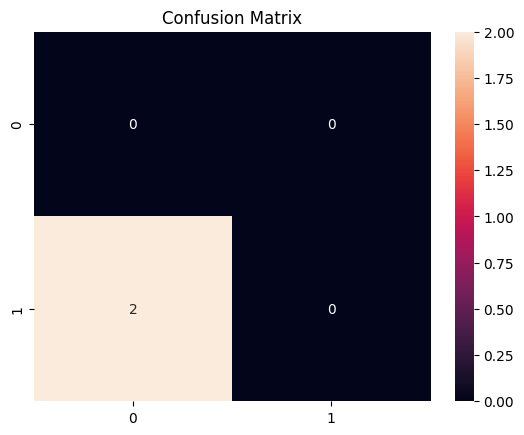

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()